<a href="https://colab.research.google.com/github/koko2585/fault-diagnosis/blob/main/03_tuning_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from lightgbm import LGBMClassifier

In [ ]:
df = pd.read_csv(r"/content/sample_data/feature_time_48k_2048_load_1.csv")

In [ ]:
X = df.drop(columns='fault')
y = df['fault']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [ ]:
# Random Forest Hyperparameter Space
rf_param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

rf_base = RandomForestClassifier(random_state=42)

rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)
print("Best RF Params:", rf_random_search.best_params_)
print("Best RF CV Accuracy:", rf_random_search.best_score_)

Best RF Params: {'max_depth': 13, 'min_samples_leaf': 4, 'min_samples_split': 6, 'n_estimators': 70}
Best RF CV Accuracy: 0.9581524444137428


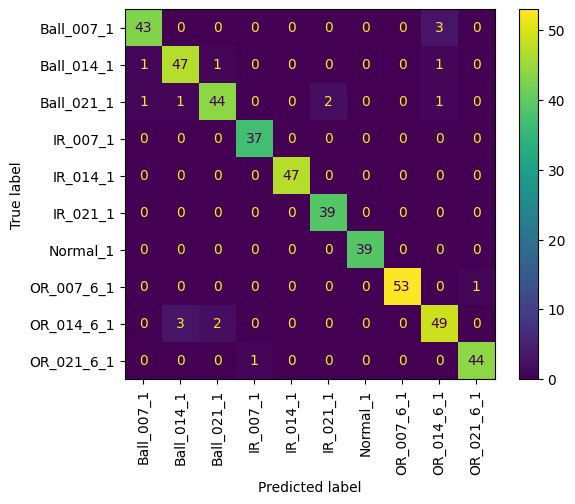

In [ ]:
# Random Forest Confusion matrix
y_pred = rf_random_search.predict(X_test
                                  )
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(xticks_rotation=90)
plt.show()

In [ ]:
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform

# LightGBM Hyperparameter Space
lgbm_param_dist = {
    'n_estimators': randint(50, 500),
    'learning_rate': uniform(0.01, 0.2),
    'num_leaves': randint(20, 150),
    'max_depth': randint(3, 12)
}

lgbm_base = LGBMClassifier(random_state=42, n_jobs=-1)

lgbm_random_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=lgbm_param_dist,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    random_state=42,
    n_jobs=-1
)

lgbm_random_search.fit(X_train, y_train)
print("Best LightGBM Params:", lgbm_random_search.best_params_)
print("Best LightGBM CV Accuracy:", lgbm_random_search.best_score_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.050895 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 1840, number of used features: 9
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.324564
[LightGBM] [Info] Start training from score -2.319024
[LightGBM] [Info] Start training from score -2.254831
[LightGBM] [Info] Start training from score -2.308035
[LightGBM] [Info] Start training from score -2.265247
[LightGBM] [Info] Start training from score -2.265247
[LightGBM] [Info] Start training from score -2.347037
[LightGBM] [Info] Start training from score -2.347037
[LightGBM] [Info] Start training from score -2.297165
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

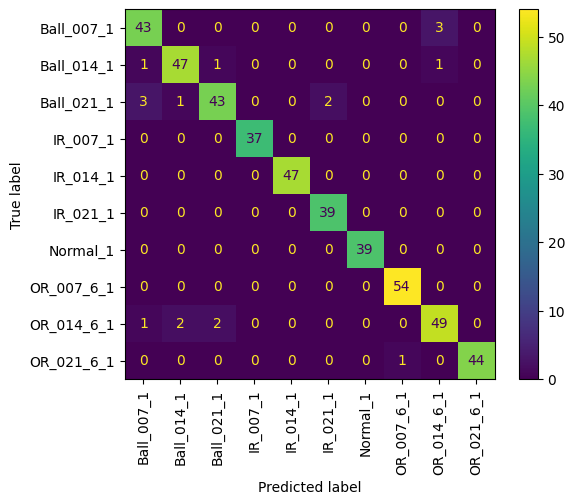

In [ ]:
# LightGBM Confusion matrix
y_pred = lgbm_random_search.predict(X_test
                                  )
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(xticks_rotation=90)
plt.show()

Now I pick the LightGBM model best parameters for  final pipeline!

In [ ]:
print("Best LightGBM Params:", lgbm_random_search.best_params_)

Best LightGBM Params: {'learning_rate': np.float64(0.19977710745066668), 'max_depth': 4, 'n_estimators': 314, 'num_leaves': 109}
